In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Data/Housing.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
price                int64
area                 int64
bedrooms             int64
bathroom

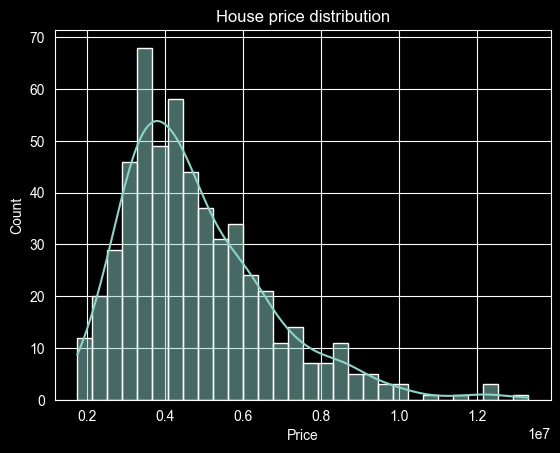

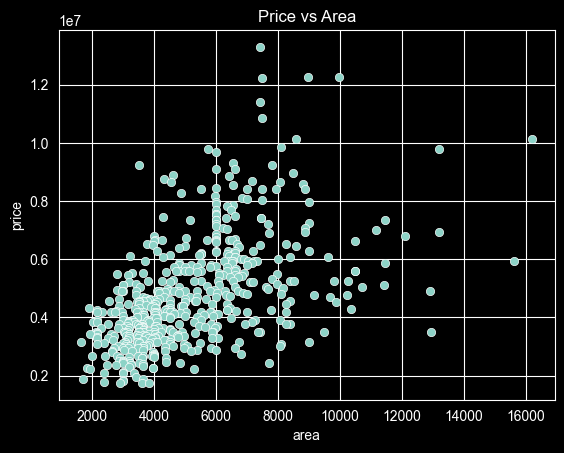

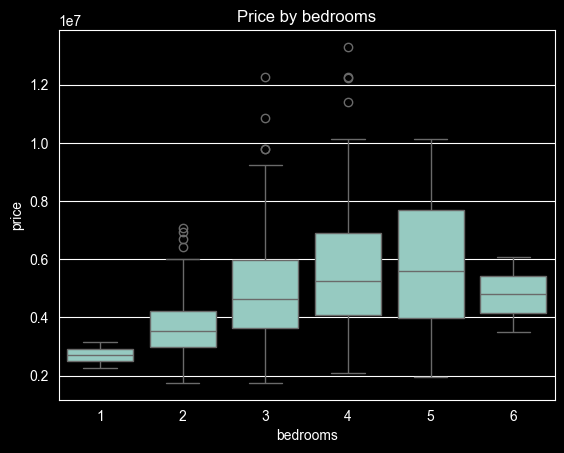

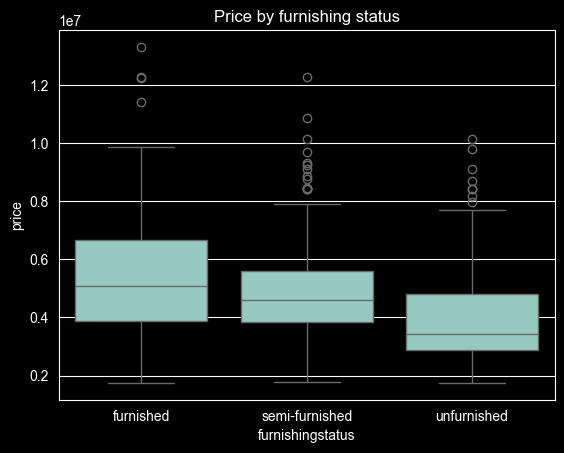

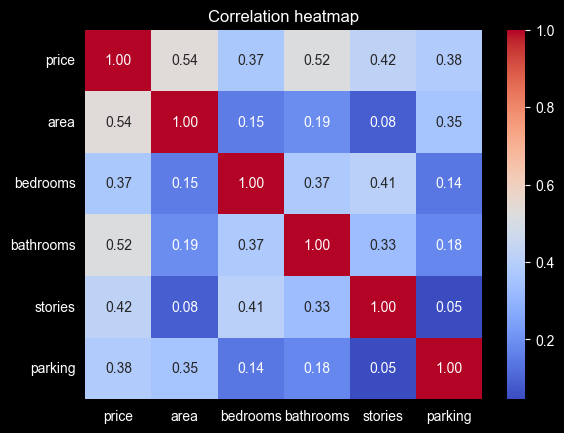

In [2]:
# Price distribution
sns.histplot(df['price'], bins=30, kde=True)
plt.title('House price distribution')
plt.xlabel('Price')
plt.show()

# Price vs Area (most important relationship)
sns.scatterplot(data=df, x='area', y='price')
plt.title('Price vs Area')
plt.show()

# Price by number of bedrooms
sns.boxplot(data=df, x='bedrooms', y='price')
plt.title('Price by bedrooms')
plt.show()

# Price by furnishing status
sns.boxplot(data=df, x='furnishingstatus', y='price')
plt.title('Price by furnishing status')
plt.show()

# Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Encode yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0
})

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train 3 models
models = {
    'Linear Regression': (LinearRegression(), X_train_sc, X_test_sc),
    'Decision Tree':     (DecisionTreeRegressor(random_state=42), X_train, X_test),
    'Random Forest':     (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test)
}

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:22} | R²: {r2:.3f} | RMSE: ₹{rmse:,.0f}")

Linear Regression      | R²: 0.649 | RMSE: ₹1,331,071
Decision Tree          | R²: 0.416 | RMSE: ₹1,718,102
Random Forest          | R²: 0.613 | RMSE: ₹1,398,901


In [4]:
# Feature engineering — create new meaningful columns
df['price_per_sqft'] = df['price'] / df['area']
df['bath_per_bed']   = df['bathrooms'] / (df['bedrooms'] + 1)
df['total_rooms']    = df['bedrooms'] + df['bathrooms']

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X_train_sc = scaler2.fit_transform(X_train)
X_test_sc  = scaler2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_sc, y_train)
preds2 = model2.predict(X_test_sc)

r2   = r2_score(y_test, preds2)
rmse = np.sqrt(mean_squared_error(y_test, preds2))
print(f"Linear Regression (with features) | R²: {r2:.3f} | RMSE: ₹{rmse:,.0f}")

Linear Regression (with features) | R²: 0.883 | RMSE: ₹768,287


In [5]:
import joblib

joblib.dump(model2, '../Models/model.pkl')
joblib.dump(scaler2, '../Models/scaler.pkl')
print("Models saved.")

# Check exact column names for app
print(X.columns.tolist())


Models saved.
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'price_per_sqft', 'bath_per_bed', 'total_rooms']
